## baseline_06: Introducing categorical features to the model
- This baseline model will do two new things:
  - Expand across multiple cartridges
  - Provide a categorical feature for the model to assess
- Will use OneHotEncoding for the categorical feature
- Will test how the model handles a much more diverse dataset

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("ridge_dataset.csv")
df.head()

,cartridge,bullet_diameter,bullet_brand,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,coal
0,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n140,112,37.2,2201,2.795
1,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n150,124,37.2,2221,2.795
2,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n540,117,38.3,2254,2.795
3,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n550,129,40.4,2267,2.795
4,308_win,0.308,berger,200_20x_hybrid_target,200.2,vihtavuori_n140,112,40.4,2372,2.795


In [12]:
numeric_features = ["charge_weight", "bullet_weight", "burn_rate_index"]
categoric_features = ["cartridge"]
target = "velocity_fps"

X = df[numeric_features + categoric_features]
y = df[target].astype(float)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoric_features)
    ]
)



In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2789, 4)  Test: (698, 4)


In [15]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)
print(f"FLOOR MAE (test): {floor_mae:.2f}ft/s")

model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])


model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
print(f"MODEL MAE (test): {model_mae:.2f}ft/s")

FLOOR MAE (test): 255.79ft/s
MODEL MAE (test): 76.59ft/s


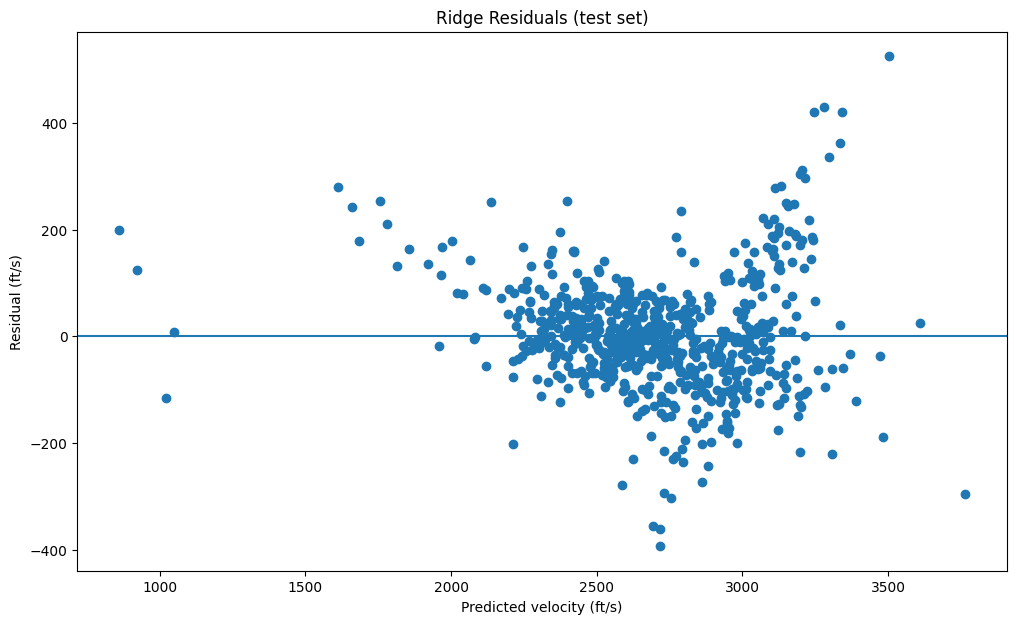

In [16]:
residuals = y_test.to_numpy() - preds

plt.figure(figsize=(12, 7))

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Ridge Residuals (test set)")
plt.show()

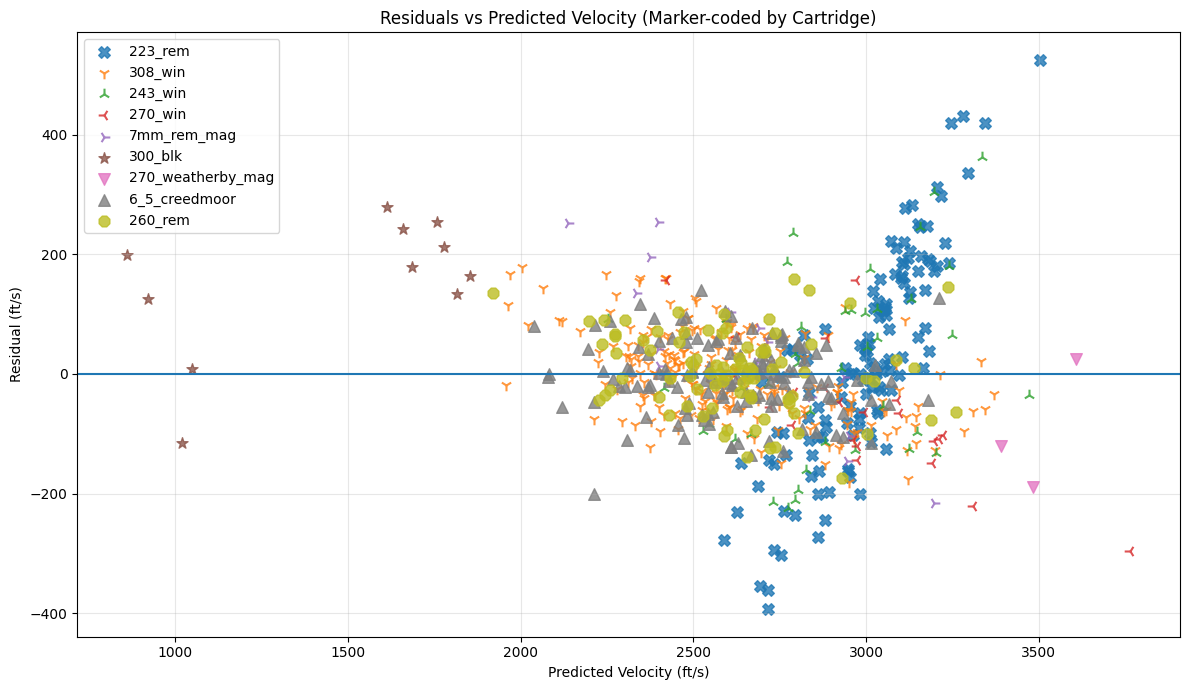

In [17]:
marker_map = {
    "223_rem": "X",
    "308_win": "1",
    "243_win": "2",
    "270_win": "3",
    "7mm_rem_mag": "4",
    "300_blk": "*",
    "270_weatherby_mag": "v",
    "6_5_creedmoor": "^",
    "260_rem": "8",
}

plt.figure(figsize=(12, 7))

for cartridge, marker in marker_map.items():
    mask = X_test["cartridge"] == cartridge
    plt.scatter(
        preds[mask],
        residuals[mask],
        marker=marker,
        s=70,
        alpha=0.8,
        label=cartridge
    )

plt.axhline(0,)
plt.xlabel("Predicted Velocity (ft/s)")
plt.ylabel("Residual (ft/s)")
plt.title("Residuals vs Predicted Velocity (Marker-coded by Cartridge)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of results:
- This was the first model to be deliberately exposed to data that did not fit nicely.
- Dataset:
  - was significantly larger than the one used in previous models
  - covered the entire lineup of all currently compiled cartridges
- This expansive set pushed our floor MAE higher
- It is important to note that the model MAE rose but it did so due to the higher floor from the more expansive dataset. The model still offered greater predictive improvement over floor than its predecessors.
- Until the dataset is again expanded, we will move forward with ~269fps and ~86fps as our new baseline floor and model MAEs (respectively) to beat
- Breaking up the residual plot by cartridge type is revealing some structures emerging that are cartridge-specific. Most notably is that the model is overpredicting slower loads and underpredicting faster loads for both the .300 Blackout and the .223 Remington cartridges.

## This reveals an import fact about the model:
- Behavior across all cartridges can not be modelled correctly by themselves
- Global development needs to be paused and model diagnosis (followed by controlled intervention) needs to now take place
- Next steps are to identify which feature(s) are causing the slope drift for our "problem" cartridges so that accurate interactions can be added to those specific cartridges.